In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
transform = transforms.ToTensor()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

BATCH_SIZE = 128

train_dataset = datasets.MNIST(
    root='../datasets',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='../datasets',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

cuda


In [3]:
class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), 
            nn.BatchNorm2d(32), 
            nn.ReLU(), 
            nn.MaxPool2d(2),   # 14x14
            nn.Conv2d(32, 64, 3, padding=1), 
            nn.BatchNorm2d(64), 
            nn.ReLU(), 
            nn.MaxPool2d(2),  # 7x7
            nn.Dropout(0.25),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)
    

In [4]:
model = DigitCNN().to(device)
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 10
losses = []
for epoch in range(EPOCHS):
    model.train()
    
    for images, labels in train_loader:
        
        # CPU → GPU
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
    
        outputs = model(images)

        loss = criterion(outputs, labels)
        losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

DigitCNN(
  (network): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Dropout(p=0.25, inplace=False)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=3136, out_features=128, bias=True)
    (11): ReLU()
    (12): Dropout(p=0.5, inplace=False)
    (13): Linear(in_features=128, out_features=10, bias=True)
  )
)
Epoch 1, Loss: 0.0868
Epoch 2, Loss: 0.0677
Epoch 3, Loss: 0.0325
Epoch 4, Loss: 0.0433
Epoch 5, Loss: 0.0201
Epoch 6, Loss: 0.0732
Epoch 7, Loss

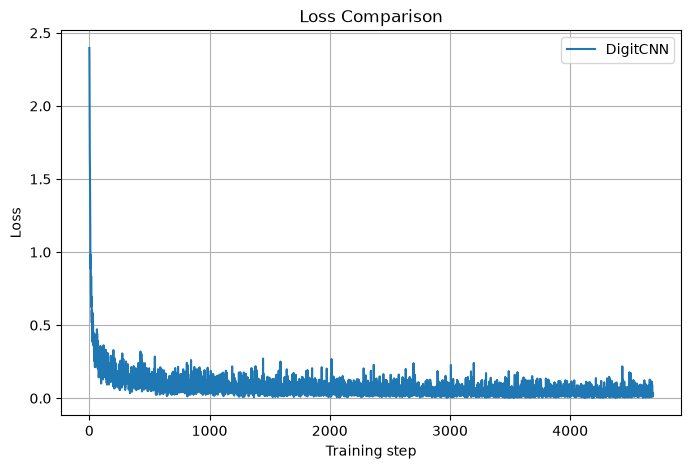

In [5]:
# =====================================
# Loss Curve Comparison
# =====================================
plt.figure(figsize=(8,5))
plt.plot(losses, label="DigitCNN")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
def evaluate(model):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            # CPU → GPU
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


acc1 = evaluate(model)

print(f"DigitCNN Test Accuracy: {acc1:.2f}%")

DigitCNN Test Accuracy: 99.09%
